In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics 
from sklearn.metrics import confusion_matrix, classification_report # Computes confusion matrix to evaluate the accuracy of a classification
from sklearn import preprocessing # Provides several common utility functions: standardization of the dataset
from sklearn.metrics import accuracy_score # Performance measure – Accuracy
from sklearn.preprocessing import StandardScaler #standarizes features
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [4]:
df = pd.read_csv("data/heart.csv")
print("Data Loaded. Shape:", df.shape)

Data Loaded. Shape: (303, 14)


In [5]:
counts = df['target'].value_counts()
print(f"Count of 0: {counts.get(0, 0)}")
print(f"Count of 1: {counts.get(1, 0)}")

Count of 0: 138
Count of 1: 165


In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.shape

(303, 14)

In [10]:
df.isnull().values.any()

np.False_

In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

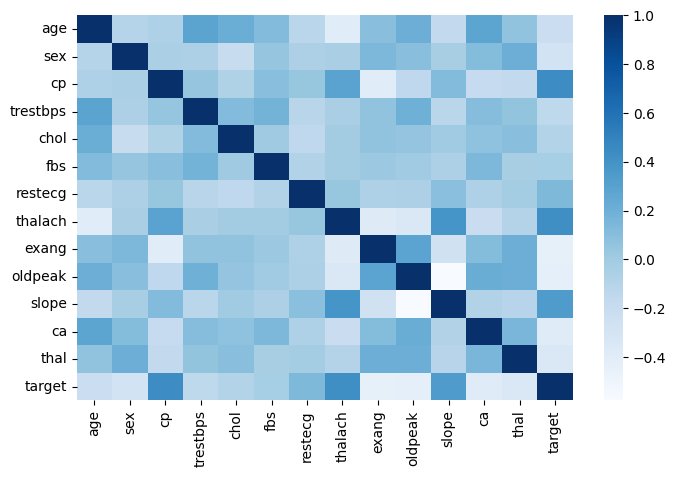

In [12]:
plt.figure(figsize = (8,5))
sns.heatmap(df.corr(), cmap = "Blues");

Checking for duplicates

In [13]:
df[df.duplicated()] 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [14]:
df=df.drop_duplicates()

In [15]:
df.shape

(302, 14)

Data Preprocessing

In [16]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [17]:
for i in df.columns:
    print(i,":", len(df[i].unique()))

age : 41
sex : 2
cp : 4
trestbps : 49
chol : 152
fbs : 2
restecg : 3
thalach : 91
exang : 2
oldpeak : 40
slope : 3
ca : 5
thal : 4
target : 2


In [18]:
categorial_val=[]
continous_val=[]
for column in df.columns:
    if df[column].nunique() <=10:
        categorial_val.append(column)
    else:
        continous_val.append(column)


In [19]:
categorial_val

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

In [20]:
continous_val

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

/tmp/ipykernel_23632/2504782043.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['target'], palette = ["darkblue", "dimgray"])


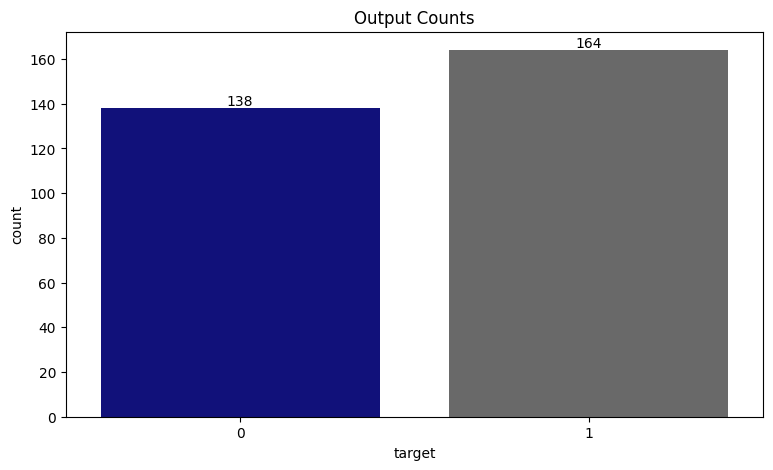

In [24]:
plt.figure(figsize = (9,5))
ax = sns.countplot(x=df['target'], palette = ["darkblue", "dimgray"])
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Output Counts");

Data Visualization

/tmp/ipykernel_23632/1396041375.py:3: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.countplot(x=col, data=df[categorial_val], hue="target",palette=sns.cubehelix_palette(len(df[col].unique()), start=.5, rot=-.75))
/tmp/ipykernel_23632/1396041375.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(x=col, data=df[categorial_val], hue="target",palette=sns.cubehelix_palette(len(df[col].unique()), start=.5, rot=-.75))
/tmp/ipykernel_23632/1396041375.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(x=col, data=df[categorial_val], hue="target",palette=sns.cubehelix_palette(len(df[col].unique()), start=.5, rot=-.75))
/tmp/ipykernel_23632/1396041375.py:3: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(x=col, data=df[categorial_val], hue="target",palett

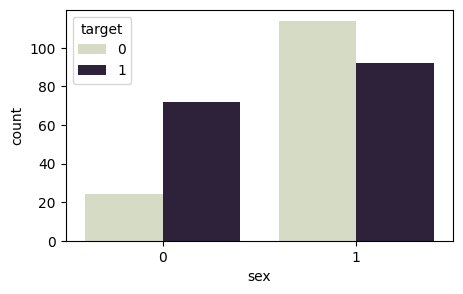

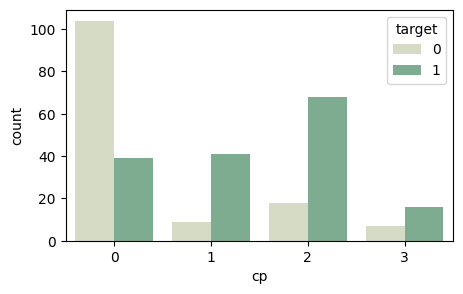

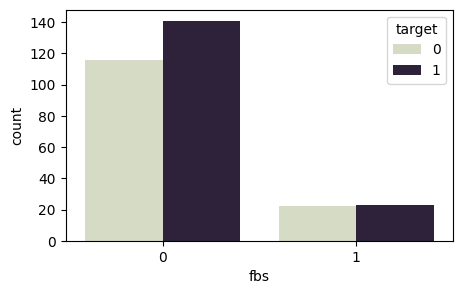

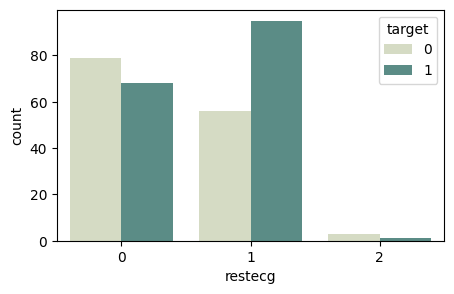

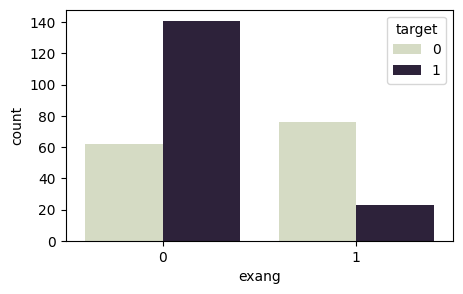

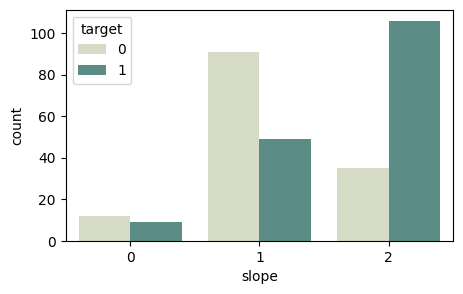

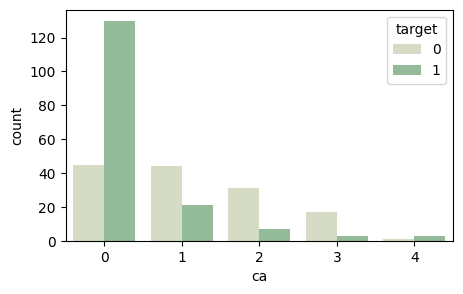

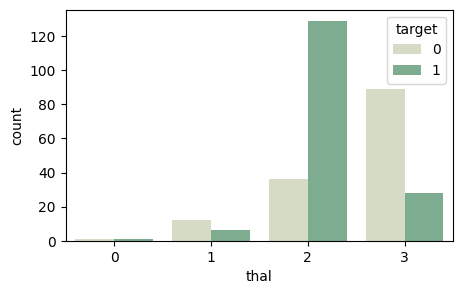

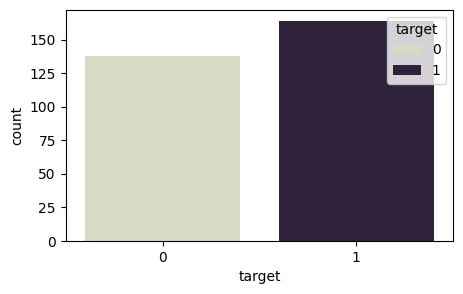

In [26]:
for col in categorial_val:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=df[categorial_val], hue="target",palette=sns.cubehelix_palette(len(df[col].unique()), start=.5, rot=-.75))

<Axes: xlabel='age', ylabel='Count'>

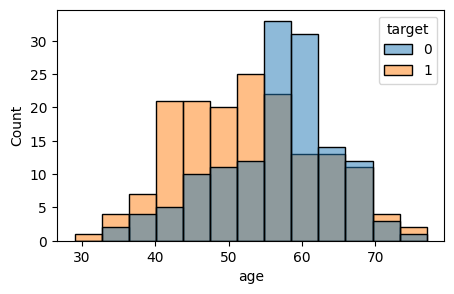

In [27]:
plt.figure(figsize=(5,3))
sns.histplot(x=df.age,hue=df['target'])

/tmp/ipykernel_23632/344841381.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y="age",data=df,palette='coolwarm')


<Axes: xlabel='target', ylabel='age'>

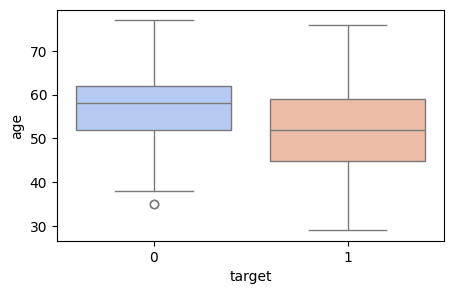

In [29]:
plt.figure(figsize=(5,3))
sns.boxplot(x='target', y="age",data=df,palette='coolwarm')

<Axes: xlabel='target', ylabel='count'>

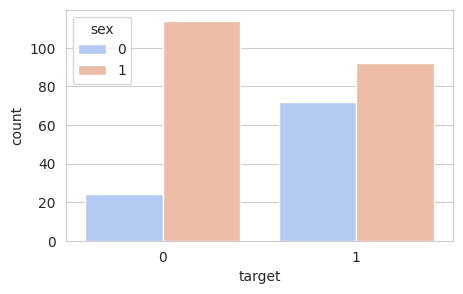

In [33]:
plt.figure(figsize=(5,3))
sns.set_style('whitegrid')
sns.countplot(x=df['target'],hue=df.sex,palette='coolwarm')

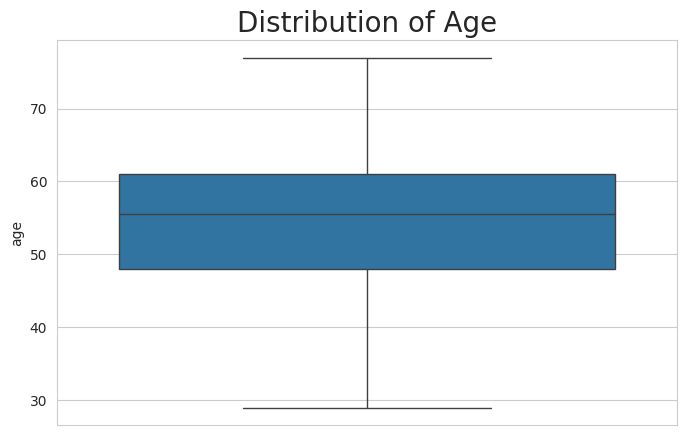

In [34]:
plt.figure(figsize = (8,5))
sns.boxplot(df.age)
plt.title("Distribution of Age", fontsize = 20);

In [35]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
df[continous_val]=st.fit_transform(df[continous_val])

In [36]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.949794,1,3,0.764066,-0.261285,1,0,0.018826,0,1.084022,0,0,1,1
1,-1.928548,1,2,-0.091401,0.067741,0,1,1.636979,0,2.118926,0,0,2,1
2,-1.485726,0,1,-0.091401,-0.822564,0,0,0.980971,0,0.307844,2,0,2,1
3,0.174856,1,1,-0.661712,-0.203222,0,1,1.243374,0,-0.209608,2,0,2,1
4,0.285561,0,0,-0.661712,2.080602,0,1,0.587366,1,-0.382092,2,0,2,1


In [39]:
x = df.drop(columns='target', axis=1)
y = df['target']
# spliting
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)
# Checking split of data
print('x training data size: {}'.format(x_train.shape))
print('y training data size: {}'.format(y_train.shape))
print('x testing data size: {}'.format(x_test.shape))
print('y testing data size: {}'.format(y_test.shape))
print("{0:0.2f}% of data is in training set".format((len(x_train)/len(df.index)) * 100))
print("{0:0.2f}% of data is in test set".format((len(x_test)/len(df.index)) * 100))

x training data size: (211, 13)
y training data size: (211,)
x testing data size: (91, 13)
y testing data size: (91,)
69.87% of data is in training set
30.13% of data is in test set


## 1. LogisticRegression


Classification accuracy: 0.8242


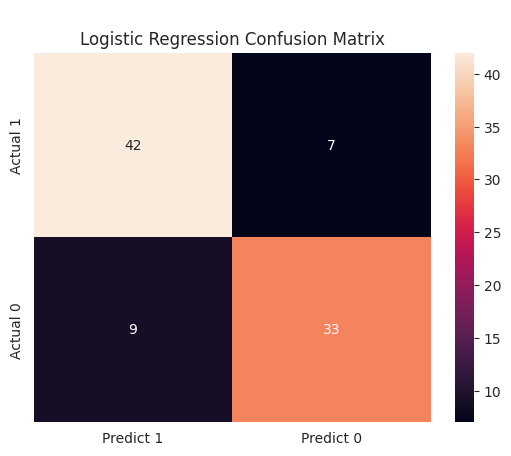

In [42]:
from sklearn.linear_model import LogisticRegression
# Model building
log_model = LogisticRegression()
log_model.fit(x_train, y_train)
log_pred = log_model.predict(x_test)
# Confusion matrix
cm=metrics.confusion_matrix(y_test, log_pred, labels=[1, 0])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual 1","Actual 0"]],
columns = [i for i in ["Predict 1","Predict 0"]])
plt.title('\nLogistic Regression Confusion Matrix')
sns.heatmap(df_cm, annot=True, fmt='g');
# Accuracy
TP = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[1,1]
#Model Evaluation
#Accuracy score
# Print classification accuracy
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)
print('\nClassification accuracy: {0:0.4f}'.format(classification_accuracy))

## 2. KNeighbors


Classification accuracy: 0.8242


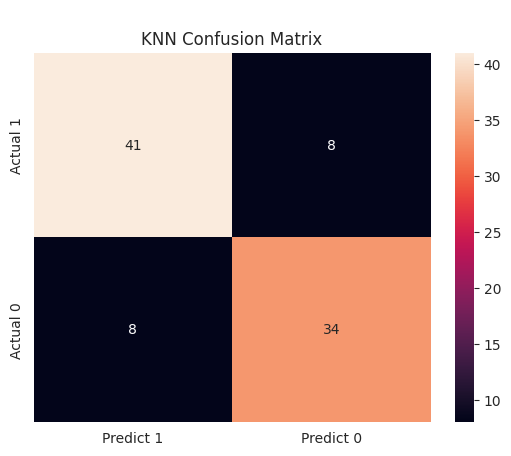

In [43]:

from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)
knn_pred=knn.predict(x_test)
accuracy_score(y_test,knn_pred)
# Confusion matrix
cm=metrics.confusion_matrix(y_test,knn_pred, labels=[1, 0])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual 1","Actual 0"]],
columns = [i for i in ["Predict 1","Predict 0"]])
plt.title('\nKNN Confusion Matrix')
sns.heatmap(df_cm, annot=True, fmt='g');
# Accuracy
TP = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[1,1]
#Model Evaluation
#Accuracy score
# Print classification accuracy
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)
print('\nClassification accuracy: {0:0.4f}'.format(classification_accuracy))

## 3. RandomForestClassifier


Classification accuracy: 0.8681


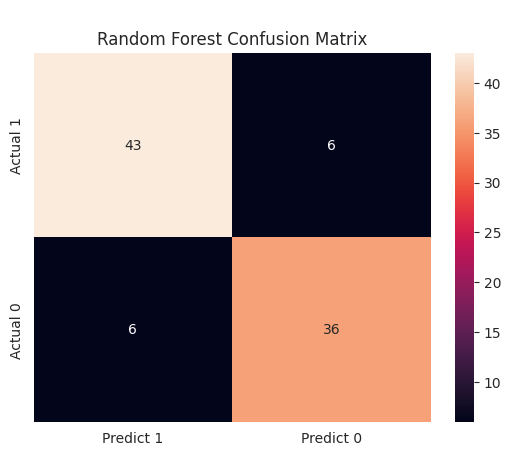

In [74]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
accuracy_score(y_test,rf_pred)
# Confusion matrix
cm=metrics.confusion_matrix(y_test,rf_pred, labels=[1, 0])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual 1","Actual 0"]],
columns = [i for i in ["Predict 1","Predict 0"]])
plt.title('\nRandom Forest Confusion Matrix')
sns.heatmap(df_cm, annot=True, fmt='g');
# Accuracy
TP = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[1,1]

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)
print('\nClassification accuracy: {0:0.4f}'.format(classification_accuracy))

## 4.Linear Support Vector Machine

In [45]:
from sklearn.svm import SVC
svclassifier = SVC(kernel='linear')
svclassifier.fit(x_train, y_train)
y_pred = svclassifier.predict(x_test)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[35  7]
 [ 8 41]]
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        42
           1       0.85      0.84      0.85        49

    accuracy                           0.84        91
   macro avg       0.83      0.84      0.83        91
weighted avg       0.84      0.84      0.84        91

0.8351648351648352



Classification accuracy: 0.8352


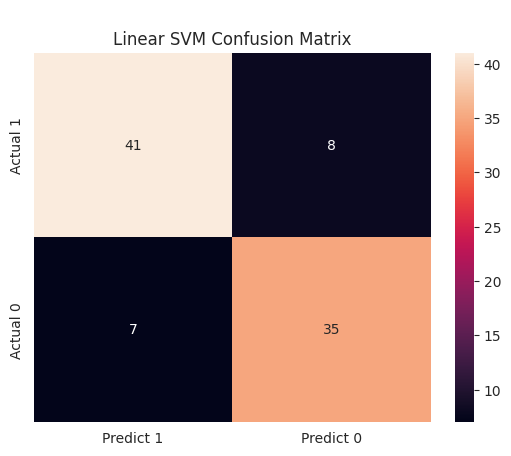

In [46]:
# Confusion matrix
cm=metrics.confusion_matrix(y_test,y_pred, labels=[1, 0])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual 1","Actual 0"]],
columns = [i for i in ["Predict 1","Predict 0"]])
plt.title('\nLinear SVM Confusion Matrix')
sns.heatmap(df_cm, annot=True, fmt='g');
# Accuracy
TP = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[1,1]
#Model Evaluation
#Accuracy score
# Print classification accuracy
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)
print('\nClassification accuracy: {0:0.4f}'.format(classification_accuracy))

## 5.Non-Linear Support Vector Machine

In [47]:
from sklearn.svm import SVC
svclassifier = SVC(kernel='poly', degree=8)
svclassifier.fit(x_train, y_train)
y_pred = svclassifier.predict(x_test)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[25 17]
 [ 4 45]]
              precision    recall  f1-score   support

           0       0.86      0.60      0.70        42
           1       0.73      0.92      0.81        49

    accuracy                           0.77        91
   macro avg       0.79      0.76      0.76        91
weighted avg       0.79      0.77      0.76        91

0.7692307692307693


In [48]:
from sklearn.svm import SVC
svclassifier = SVC(kernel='rbf')
svclassifier.fit(x_train, y_train)
y_pred = svclassifier.predict(x_test)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[35  7]
 [ 7 42]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        42
           1       0.86      0.86      0.86        49

    accuracy                           0.85        91
   macro avg       0.85      0.85      0.85        91
weighted avg       0.85      0.85      0.85        91

0.8461538461538461



Classification accuracy: 0.8462


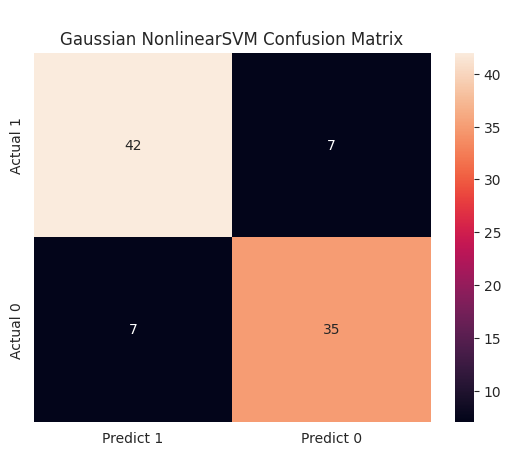

In [49]:
# Confusion matrix
cm=metrics.confusion_matrix(y_test,y_pred, labels=[1, 0])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual 1","Actual 0"]],
columns = [i for i in ["Predict 1","Predict 0"]])
plt.title('\nGaussian NonlinearSVM Confusion Matrix')
sns.heatmap(df_cm, annot=True, fmt='g');
# Accuracy
TP = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[1,1]
#Model Evaluation
#Accuracy score
# Print classification accuracy
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)
print('\nClassification accuracy: {0:0.4f}'.format(classification_accuracy))

In [50]:
from sklearn.svm import SVC
svclassifier = SVC(kernel='sigmoid')
svclassifier.fit(x_train, y_train)
y_pred = svclassifier.predict(x_test)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[31 11]
 [ 5 44]]
              precision    recall  f1-score   support

           0       0.86      0.74      0.79        42
           1       0.80      0.90      0.85        49

    accuracy                           0.82        91
   macro avg       0.83      0.82      0.82        91
weighted avg       0.83      0.82      0.82        91

0.8241758241758241



Classification accuracy: 0.8242


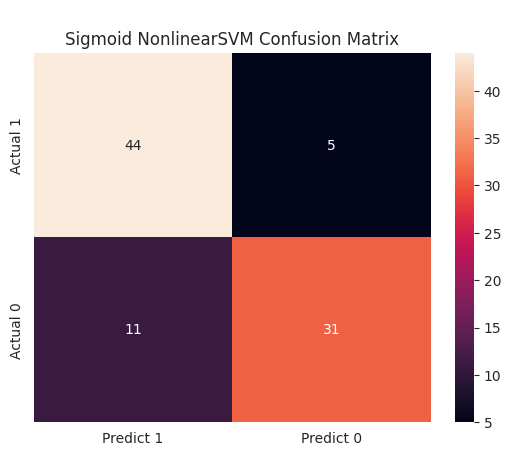

In [51]:
# Confusion matrix
cm=metrics.confusion_matrix(y_test,y_pred, labels=[1, 0])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual 1","Actual 0"]],
columns = [i for i in ["Predict 1","Predict 0"]])
plt.title('\nSigmoid NonlinearSVM Confusion Matrix')
sns.heatmap(df_cm, annot=True, fmt='g');
# Accuracy
TP = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[1,1]
#Model Evaluation
#Accuracy score
# Print classification accuracy
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)
print('\nClassification accuracy: {0:0.4f}'.format(classification_accuracy))

## 6. Boosting Classifier


Misclassified samples in Bagging: 14


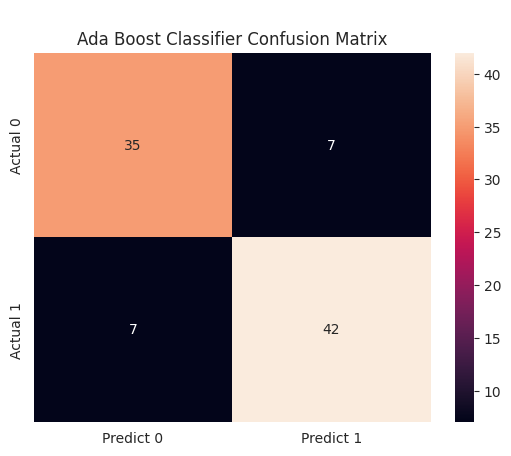

In [55]:
from sklearn.ensemble import AdaBoostClassifier
abc1 =AdaBoostClassifier(n_estimators=10,random_state=1)
abc1 = abc1.fit(x_train, y_train)
abc1_y_predict = abc1.predict(x_test)
misclassified_count=(y_test != abc1_y_predict).sum() 
print("\nMisclassified samples in Bagging:", misclassified_count)
cm = metrics.confusion_matrix(y_test,abc1_y_predict,labels=[0,1]) 
df_cm = pd.DataFrame(cm, index=[i for i in ["Actual 0","Actual 1"]], columns= [i for i in ["Predict 0","Predict 1"]])
plt.title("\nAda Boost Classifier Confusion Matrix") 
sns.heatmap(df_cm, annot=True, fmt='g');

In [56]:
a = accuracy_score(y_test, abc1_y_predict)
p = precision_score(y_test, abc1_y_predict) 
r = recall_score(y_test, abc1_y_predict)
f = f1_score (y_test, abc1_y_predict)
print("Accuracy : ",round (a,2))
print("Precision : ", round(p,2))
print("Recall : ",round(r,2))
print("FI score ", round(f,2))

Accuracy :  0.85
Precision :  0.86
Recall :  0.86
FI score  0.86



Misclassified samples in Bagging: 14


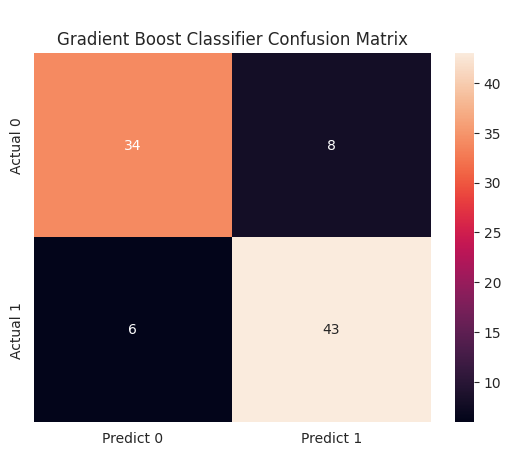

In [57]:
from sklearn.ensemble import GradientBoostingClassifier
gbc1 =GradientBoostingClassifier(n_estimators=10,random_state=1)
gbc1 = gbc1.fit(x_train, y_train)
gbc1_y_predict = gbc1.predict(x_test)
misclassified_count=(y_test != gbc1_y_predict).sum() 
print("\nMisclassified samples in Bagging:", misclassified_count)
cm = metrics.confusion_matrix(y_test,gbc1_y_predict,labels=[0,1]) 
df_cm = pd.DataFrame(cm, index=[i for i in ["Actual 0","Actual 1"]], columns= [i for i in ["Predict 0","Predict 1"]])
plt.title("\nGradient Boost Classifier Confusion Matrix") 
sns.heatmap(df_cm, annot=True, fmt='g');

In [58]:
a = accuracy_score(y_test, gbc1_y_predict)
p = precision_score(y_test, gbc1_y_predict) 
r = recall_score(y_test, gbc1_y_predict)
f = f1_score (y_test, gbc1_y_predict)
print("Accuracy : ",round (a,2))
print("Precision : ", round(p,2))
print("Recall : ",round(r,2))
print("FI score ", round(f,2))

Accuracy :  0.85
Precision :  0.84
Recall :  0.88
FI score  0.86


In [60]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
accuracy_score(y_test,y_pred)

0.8241758241758241


Classification accuracy: 0.8242


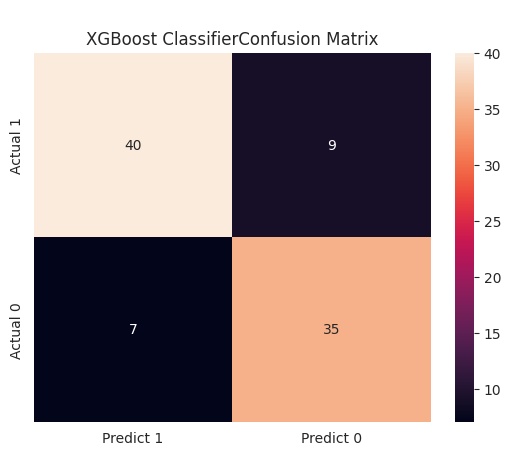

In [61]:
# Confusion matrix
cm=metrics.confusion_matrix(y_test,y_pred, labels=[1, 0])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual 1","Actual 0"]],
columns = [i for i in ["Predict 1","Predict 0"]])
plt.title('\nXGBoost ClassifierConfusion Matrix')
sns.heatmap(df_cm, annot=True, fmt='g');
# Accuracy
TP = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[1,1]
#Model Evaluation
#Accuracy score
# Print classification accuracy
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)
print('\nClassification accuracy: {0:0.4f}'.format(classification_accuracy))

## 7. Decision Tree Classifier

In [62]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion='gini',random_state=1)
dt.fit(x_train,y_train)
dt_pred=dt.predict(x_test)
accuracy_score(y_test,dt_pred)

0.8131868131868132


Classification accuracy: 0.8132


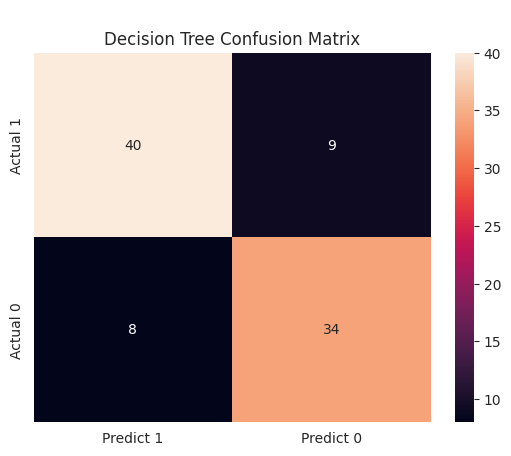

In [63]:
# Confusion matrix
cm=metrics.confusion_matrix(y_test,dt_pred, labels=[1, 0])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual 1","Actual 0"]],
columns = [i for i in ["Predict 1","Predict 0"]])
plt.title('\nDecision Tree Confusion Matrix')
sns.heatmap(df_cm, annot=True, fmt='g');
# Accuracy
TP = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[1,1]
#Model Evaluation
#Accuracy score
# Print classification accuracy
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)
print('\nClassification accuracy: {0:0.4f}'.format(classification_accuracy))

## 8. Naive Bayes

Classification accuracy without scaling: 0.8462


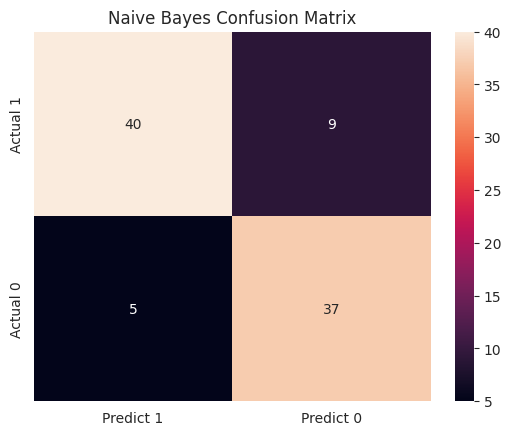

In [64]:
from sklearn.naive_bayes import GaussianNB
gnb_model = GaussianNB()
gnb_model.fit(x_train, y_train)
gnb_pred = gnb_model.predict(x_test)
cm=metrics.confusion_matrix(y_test, gnb_pred, labels=[1, 0])
df_cm = pd.DataFrame(cm, index = [i for i in ["Actual 1","Actual 0"]],
columns = [i for i in ["Predict 1","Predict 0"]])
plt.title('Naive Bayes Confusion Matrix')
sns.heatmap(df_cm, annot=True, fmt='g');
# Accuracy
TP = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[1,1]
# Print classification accuracy
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)
print('Classification accuracy without scaling: {0:0.4f}'.format(classification_accuracy))

In [75]:
final_data=pd.DataFrame({'Models':['LR','KNN','RF','SVM','Poly','rbf','Sig','AB','Gb','XgB','DF','NB'],
                        'Accuracy':[accuracy_score(y_test,log_pred),
                                    accuracy_score(y_test,knn_pred),
                                    accuracy_score(y_test,rf_pred),
                                    accuracy_score(y_test,y_pred),
                                    accuracy_score(y_test,y_pred),
                                    accuracy_score(y_test,y_pred),
                                    accuracy_score(y_test,y_pred),
                                    accuracy_score(y_test,abc1_y_predict),
                                    accuracy_score(y_test,gbc1_y_predict),
                                    accuracy_score(y_test,y_pred),
                                    accuracy_score(y_test,dt_pred),
                                    accuracy_score(y_test,gnb_pred)]})

In [76]:
final_data

,Models,Accuracy
0,LR,0.824176
1,KNN,0.824176
2,RF,0.868132
3,SVM,0.824176
4,Poly,0.824176
5,rbf,0.824176
6,Sig,0.824176
7,AB,0.846154
8,Gb,0.846154
9,XgB,0.824176


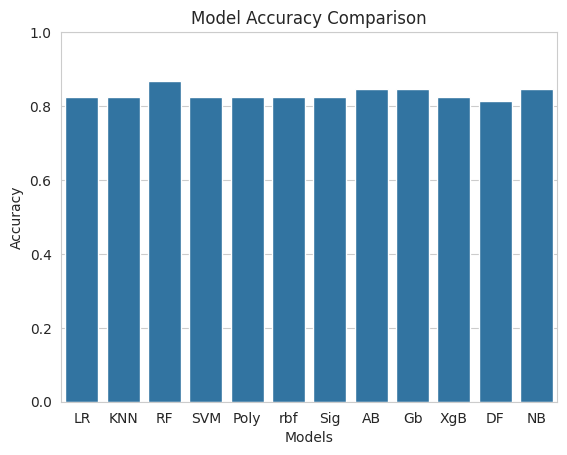

In [77]:
sns.barplot(x='Models', y='Accuracy', data=final_data)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.show()

In [81]:
import joblib
joblib.dump(rf, 'models/best_model.pkl')

['models/best_model.pkl']